## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../../Mamoth Modules")
sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [3]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)


In [4]:
dataset

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,αθηνων,αττικης,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14624.000000,14325.000000,14624.000000,NaN,NaN,NaN,14325.000000,NaN,NaN,NaN,0.000000
1,αθηνων,αττικης,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14049.000000,14193.000000,14336.500000,NaN,NaN,NaN,14259.000000,NaN,NaN,NaN,0.000000
2,αθηνων,αττικης,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14240.666667,NaN,NaN,NaN,14197.333333,NaN,NaN,NaN,0.000000
3,αθηνων,αττικης,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14192.750000,NaN,NaN,NaN,14166.500000,NaN,NaN,NaN,0.000000
4,αθηνων,αττικης,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14164.000000,NaN,NaN,NaN,14148.000000,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-27,27,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,14467.000000,14238.000000,14250.322581,14437.178571,14565.516129,14565.516129,13998.354839,14044.642857,13991.677419,13991.677419,0.000000
3029220,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-28,28,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,14494.000000,14205.000000,14250.322581,14437.178571,14565.516129,14565.516129,13998.354839,14044.642857,13991.677419,13991.677419,0.000000
3029221,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-29,29,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,14494.000000,14144.000000,14250.322581,14437.178571,14565.516129,14565.516129,13998.354839,14044.642857,13991.677419,13991.677419,0.000000
3029222,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-30,30,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,14433.000000,14246.000000,14250.322581,14437.178571,14565.516129,14565.516129,13998.354839,14044.642857,13991.677419,13991.677419,0.000000


In [5]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [6]:
dataset.shape

(3029224, 31)

In [7]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [8]:
dataset2 = pd.DataFrame()
groups = dataset.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset2 = dataset2.append(temp_df)

dataset2.reset_index(drop=True, inplace=True)

In [9]:
dataset2

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,πειραιως και νησων,αττικης,22.924050,36.226730,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14540.000000,14327.000000,14540.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,πειραιως και νησων,αττικης,22.924050,36.226730,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.000000,14327.000000,14464.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,πειραιως και νησων,αττικης,22.924050,36.226730,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14327.000000,14428.666667,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,πειραιως και νησων,αττικης,22.924050,36.226730,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14164.000000,14327.000000,14362.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
4,πειραιως και νησων,αττικης,22.924050,36.226730,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14348.000000,14180.000000,14359.600000,NaN,NaN,NaN,14297.600000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,ανατολικης αττικης,αττικης,24.050870,37.792680,2022-12-27,27,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14207.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,0.012201,1.284521,767.502467
3029220,ανατολικης αττικης,αττικης,24.050870,37.792680,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.000000,14147.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,0.012201,1.265016,767.502467
3029221,ανατολικης αττικης,αττικης,24.050870,37.792680,2022-12-29,29,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14149.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,0.012201,0.012201,767.502467
3029222,ανατολικης αττικης,αττικης,24.050870,37.792680,2022-12-30,30,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14125.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,0.000000,0.012201,767.502467


In [10]:
grouped = dataset2.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,αθηνων,αττικης,23.761339,37.995939,1.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14583.357143,14282.327273,14583.357143,NaN,NaN,NaN,14282.327273,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,2010-01-01,ανατολικης αττικης,αττικης,23.889386,38.042726,1.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14586.219512,NaN,NaN,NaN,14249.841379,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,2010-01-01,δυτικης αττικης,αττικης,23.393515,38.090792,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14563.811518,14194.581152,14563.811518,NaN,NaN,NaN,14194.581152,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14631.560000,14327.549296,14631.560000,NaN,NaN,NaN,14327.549296,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
4,2010-01-02,αθηνων,αττικης,23.761339,37.995939,2.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14424.678571,14180.464286,14504.017857,NaN,NaN,NaN,14231.062500,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,πειραιως και νησων,αττικης,23.209892,37.000012,30.000000,12.000000,2022.000000,0.450630,0.194090,-0.336309,-0.194090,0.445607,0.188515,-0.334842,-0.188515,0.050421,0.056673,0.057526,0.056673,14368.300000,14119.750000,14261.464516,14358.587500,14380.178710,14380.178710,13951.168065,13990.993929,13928.746452,13928.746452,0.000000,0.187398,1.779899,1406.339292
18988,2022-12-31,αθηνων,αττικης,23.761339,37.995939,31.000000,12.000000,2022.000000,0.196736,0.089225,-0.175720,-0.089225,0.201940,0.083988,-0.180670,-0.083988,0.059159,0.041055,0.047088,0.041055,14402.107143,14106.821429,14168.471774,14379.640306,14451.788594,14451.788594,13894.442972,13993.869260,13899.648041,13899.648041,0.000000,0.000000,0.384475,838.684709
18989,2022-12-31,ανατολικης αττικης,αττικης,23.889386,38.042726,31.000000,12.000000,2022.000000,0.357294,0.096638,-0.294180,-0.096638,0.350256,0.100488,-0.286339,-0.100488,0.052750,0.056148,0.048111,0.056148,14342.862069,13992.941379,14168.732703,14338.747783,14342.089878,14342.089878,13827.806229,13896.748030,13820.299889,13820.299889,0.000000,0.000380,0.115781,935.296726
18990,2022-12-31,δυτικης αττικης,αττικης,23.393515,38.090792,31.000000,12.000000,2022.000000,0.342190,0.097829,-0.273326,-0.097829,0.344352,0.098926,-0.275504,-0.098926,0.064567,0.066426,0.069173,0.066426,14331.010417,13957.661458,14110.382560,14294.838356,14340.708165,14340.708165,13799.250504,13858.337426,13799.106015,13799.106015,0.000000,0.000000,0.047329,970.382979


In [11]:
dataset.shape

(18992, 34)

In [12]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [13]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,αθηνων,αττικης,23.761339,37.995939,1.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14583.357143,14282.327273,14583.357143,NaN,NaN,NaN,14282.327273,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,2010-01-01,ανατολικης αττικης,αττικης,23.889386,38.042726,1.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14586.219512,NaN,NaN,NaN,14249.841379,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,2010-01-01,δυτικης αττικης,αττικης,23.393515,38.090792,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14563.811518,14194.581152,14563.811518,NaN,NaN,NaN,14194.581152,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14631.560000,14327.549296,14631.560000,NaN,NaN,NaN,14327.549296,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
4,2010-01-02,αθηνων,αττικης,23.761339,37.995939,2.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14424.678571,14180.464286,14504.017857,NaN,NaN,NaN,14231.062500,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,πειραιως και νησων,αττικης,23.209892,37.000012,30.000000,12.000000,2022.000000,0.450630,0.194090,-0.336309,-0.194090,0.445607,0.188515,-0.334842,-0.188515,0.050421,0.056673,0.057526,0.056673,14368.300000,14119.750000,14261.464516,14358.587500,14380.178710,14380.178710,13951.168065,13990.993929,13928.746452,13928.746452,0.000000,0.187398,1.779899,1406.339292
18988,2022-12-31,αθηνων,αττικης,23.761339,37.995939,31.000000,12.000000,2022.000000,0.196736,0.089225,-0.175720,-0.089225,0.201940,0.083988,-0.180670,-0.083988,0.059159,0.041055,0.047088,0.041055,14402.107143,14106.821429,14168.471774,14379.640306,14451.788594,14451.788594,13894.442972,13993.869260,13899.648041,13899.648041,0.000000,0.000000,0.384475,838.684709
18989,2022-12-31,ανατολικης αττικης,αττικης,23.889386,38.042726,31.000000,12.000000,2022.000000,0.357294,0.096638,-0.294180,-0.096638,0.350256,0.100488,-0.286339,-0.100488,0.052750,0.056148,0.048111,0.056148,14342.862069,13992.941379,14168.732703,14338.747783,14342.089878,14342.089878,13827.806229,13896.748030,13820.299889,13820.299889,0.000000,0.000380,0.115781,935.296726
18990,2022-12-31,δυτικης αττικης,αττικης,23.393515,38.090792,31.000000,12.000000,2022.000000,0.342190,0.097829,-0.273326,-0.097829,0.344352,0.098926,-0.275504,-0.098926,0.064567,0.066426,0.069173,0.066426,14331.010417,13957.661458,14110.382560,14294.838356,14340.708165,14340.708165,13799.250504,13858.337426,13799.106015,13799.106015,0.000000,0.000000,0.047329,970.382979


In [14]:
# dataset['lst_jan_mean'] = (dataset['lst_day_jan_mean'] + dataset['lst_night_jan_mean'])/2
# dataset['lst_feb_mean'] = (dataset['lst_day_feb_mean'] + dataset['lst_night_feb_mean'])/2
# dataset['lst_mar_mean'] = (dataset['lst_day_mar_mean'] + dataset['lst_night_mar_mean'])/2
# dataset['lst_apr_mean'] = (dataset['lst_day_apr_mean'] + dataset['lst_night_apr_mean'])/2

In [15]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [16]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [17]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αθηνων,αττικης,23.761339,37.995939,1,1,2010,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14583.357143,14282.327273,14583.357143,NaN,NaN,NaN,14282.327273,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,ανατολικης αττικης,αττικης,23.889386,38.042726,1,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14586.219512,NaN,NaN,NaN,14249.841379,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,δυτικης αττικης,αττικης,23.393515,38.090792,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14563.811518,14194.581152,14563.811518,NaN,NaN,NaN,14194.581152,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14631.560000,14327.549296,14631.560000,NaN,NaN,NaN,14327.549296,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-02,αθηνων,αττικης,23.761339,37.995939,2,1,2010,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14424.678571,14180.464286,14504.017857,NaN,NaN,NaN,14231.062500,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,πειραιως και νησων,αττικης,23.209892,37.000012,30,12,2022,0.450630,0.194090,-0.336309,-0.194090,0.445607,0.188515,-0.334842,-0.188515,0.050421,0.056673,0.057526,0.056673,14368.300000,14119.750000,14261.464516,14358.587500,14380.178710,14380.178710,13951.168065,13990.993929,13928.746452,13928.746452,0.000000,0.187398,1.779899,1406.339292,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981
18988,2022-12-31,αθηνων,αττικης,23.761339,37.995939,31,12,2022,0.196736,0.089225,-0.175720,-0.089225,0.201940,0.083988,-0.180670,-0.083988,0.059159,0.041055,0.047088,0.041055,14402.107143,14106.821429,14168.471774,14379.640306,14451.788594,14451.788594,13894.442972,13993.869260,13899.648041,13899.648041,0.000000,0.000000,0.384475,838.684709,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18989,2022-12-31,ανατολικης αττικης,αττικης,23.889386,38.042726,31,12,2022,0.357294,0.096638,-0.294180,-0.096638,0.350256,0.100488,-0.286339,-0.100488,0.052750,0.056148,0.048111,0.056148,14342.862069,13992.941379,14168.732703,14338.747783,14342.089878,14342.089878,13827.806229,13896.748030,13820.299889,13820.299889,0.000000,0.000380,0.115781,935.296726,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18990,2022-12-31,δυτικης αττικης,αττικης,23.393515,38.090792,31,12,2022,0.342190,0.097829,-0.273326,-0.097829,0.344352,0.098926,-0.275504,-0.098926,0.064567,0.066426,0.069173,0.066426,14331.010417,13957.661458,14110.382560,14294.838356,14340.708165,14340.708165,13799.250504,13858.337426,13799.106015,13799.106015,0.000000,0.000000,0.047329,970.382979,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [18]:
dataset.reset_index(drop=True, inplace=True)

<AxesSubplot:>

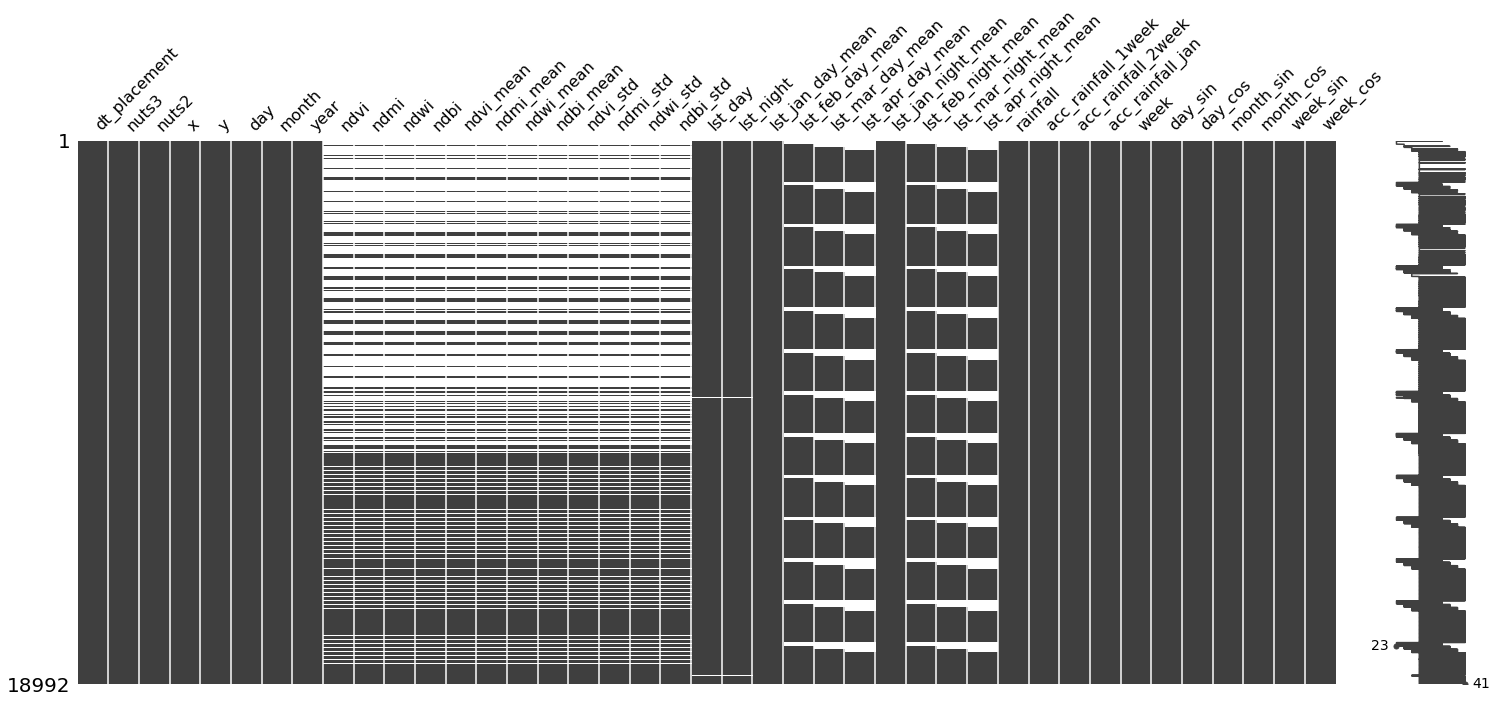

In [19]:
missingno.matrix(dataset)

In [20]:
print(dataset.columns)

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'day', 'month', 'year',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean',
       'lst_apr_day_mean', 'lst_jan_night_mean', 'lst_feb_night_mean',
       'lst_mar_night_mean', 'lst_apr_night_mean', 'rainfall',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 'week',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos'],
      dtype='object')


In [21]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [22]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [23]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == 'κεντρικης μακεδονιας'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [24]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [25]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


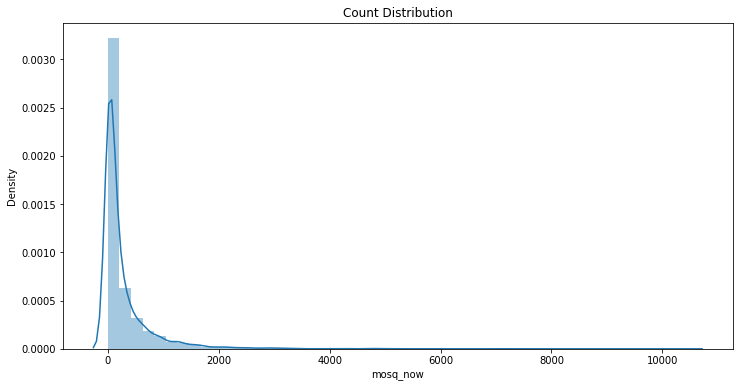

In [26]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [27]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_23136/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


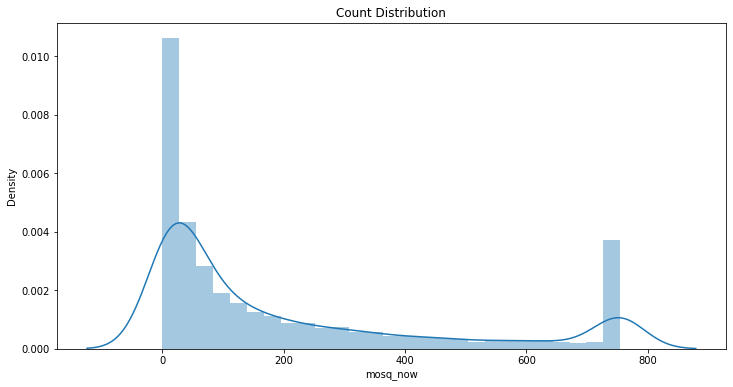

In [28]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

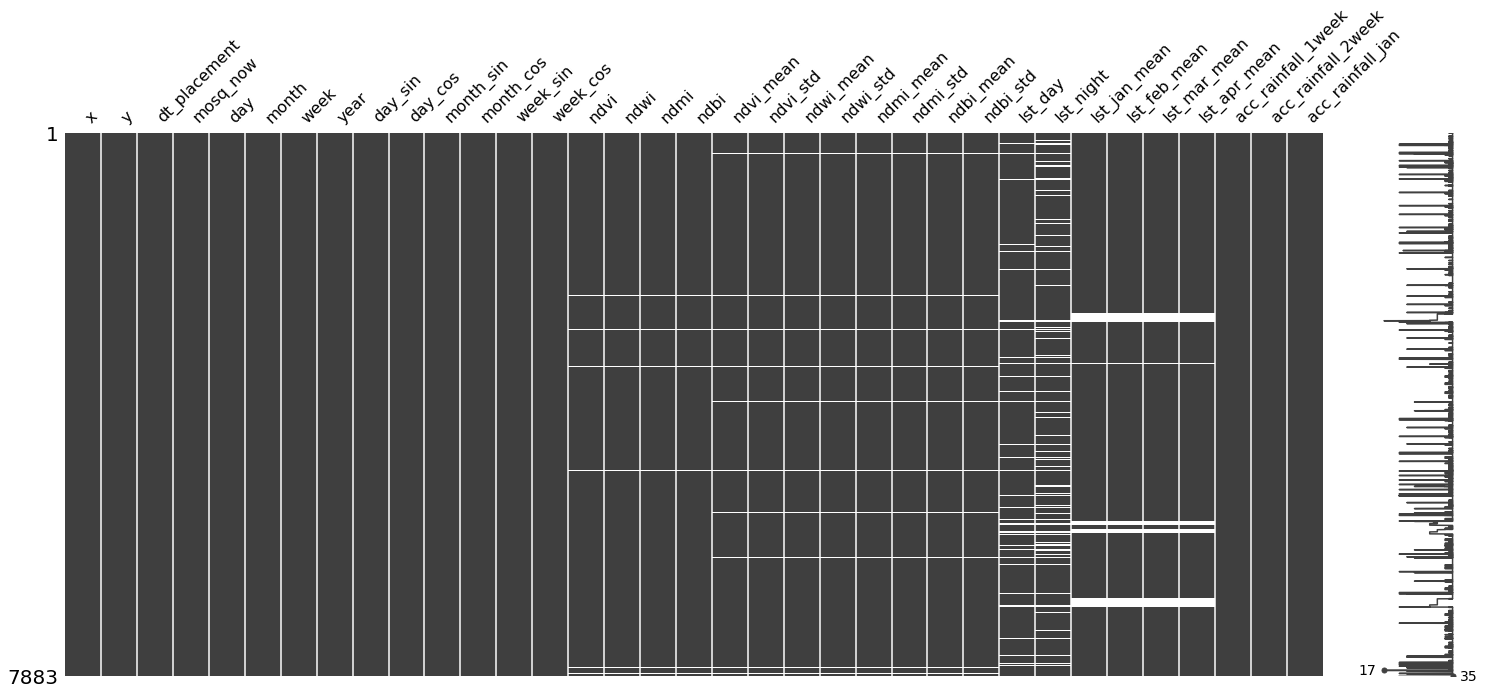

In [29]:
missingno.matrix(mosquito_data_nuts2)

In [30]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [31]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

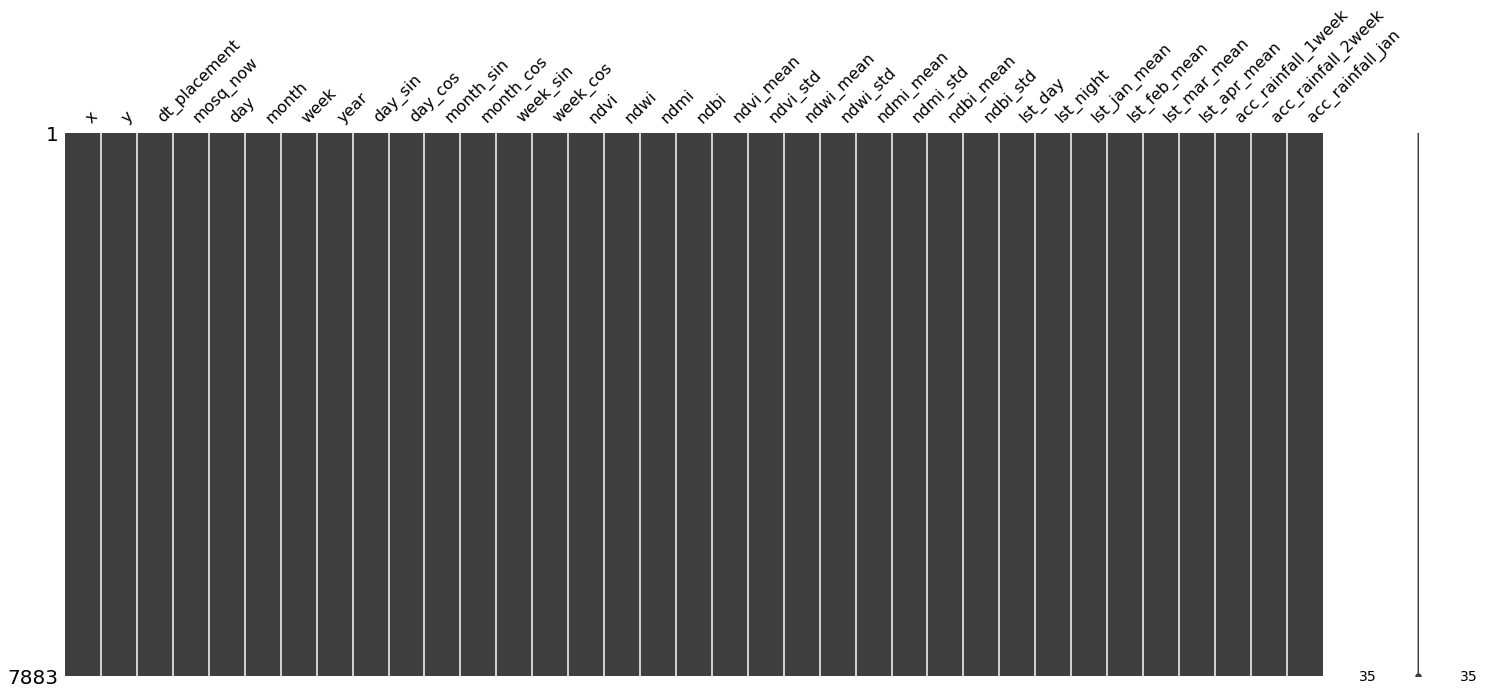

In [32]:
missingno.matrix(mosquito_data_nuts2)

In [33]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [34]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [35]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.64448 | Val Loss: 24.99000 | Train Acc: 2.668| Val Acc: 1.967
Epoch 002: | Train Loss: 18.65070 | Val Loss: 25.16957 | Train Acc: 2.247| Val Acc: 2.045
Epoch 003: | Train Loss: 18.13148 | Val Loss: 25.55684 | Train Acc: 2.176| Val Acc: 2.075
Epoch 004: | Train Loss: 17.95577 | Val Loss: 24.88508 | Train Acc: 2.121| Val Acc: 2.008
Epoch 005: | Train Loss: 17.80865 | Val Loss: 24.06883 | Train Acc: 2.108| Val Acc: 1.930
Epoch 006: | Train Loss: 17.42075 | Val Loss: 23.86087 | Train Acc: 2.046| Val Acc: 1.962
Epoch 007: | Train Loss: 17.19661 | Val Loss: 23.83241 | Train Acc: 2.047| Val Acc: 1.997
Epoch 008: | Train Loss: 17.21590 | Val Loss: 23.79085 | Train Acc: 2.037| Val Acc: 1.953
Epoch 009: | Train Loss: 17.03050 | Val Loss: 24.09033 | Train Acc: 2.027| Val Acc: 2.017
Epoch 010: | Train Loss: 16.72346 | Val Loss: 24.24388 | Train Acc: 1.998| Val Acc: 2.005
Epoch 011: | Train Loss: 16.63767 | Val Loss: 24.19443 | Train Acc: 2.004| Val Acc: 2.041
Epoch 012:

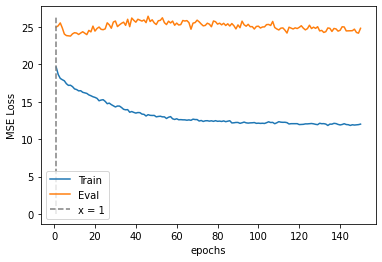

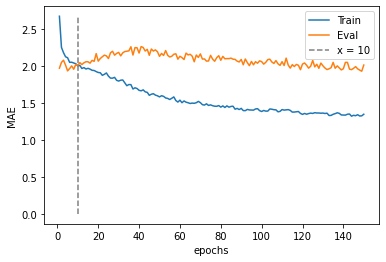

In [36]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [37]:
metrics(train, test, threshold=30)

MAE on train set:  153.08428809517764
min prediction: 1
max prediction: 1935

MAE on test set:  168.67847901175003
Error ⩽ 30: 18.26 %
min prediction: 1
max prediction: 1345


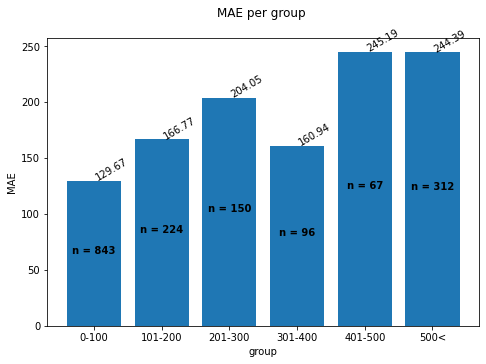

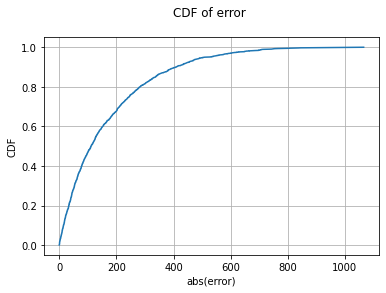

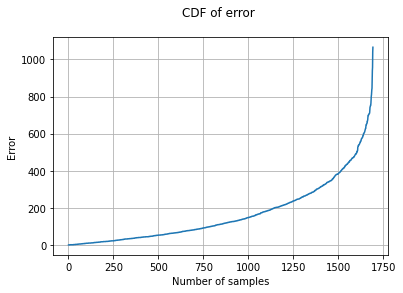

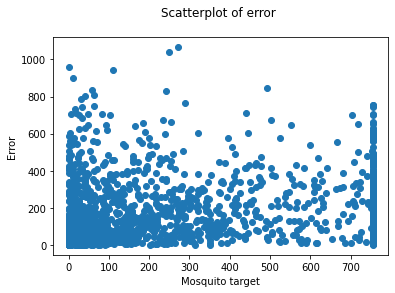

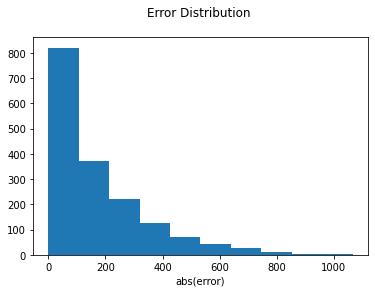

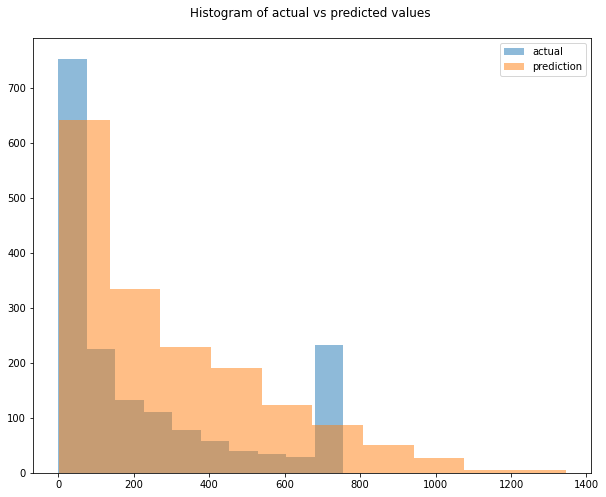

In [38]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.64570 | Val Loss: 2.42480 | Train Acc: 1.542| Val Acc: 1.633
Epoch 002: | Train Loss: 13.63823 | Val Loss: 3.75846 | Train Acc: 1.566| Val Acc: 1.633
Epoch 003: | Train Loss: 13.75611 | Val Loss: 5.08993 | Train Acc: 1.573| Val Acc: 2.633
Epoch 004: | Train Loss: 13.26629 | Val Loss: 4.14265 | Train Acc: 1.495| Val Acc: 1.633
Epoch 005: | Train Loss: 13.34047 | Val Loss: 1.91981 | Train Acc: 1.519| Val Acc: 1.633
Epoch 006: | Train Loss: 13.26125 | Val Loss: 3.10363 | Train Acc: 1.492| Val Acc: 1.633
Epoch 007: | Train Loss: 13.47080 | Val Loss: 6.22091 | Train Acc: 1.537| Val Acc: 2.633
Epoch 008: | Train Loss: 13.04113 | Val Loss: 3.32641 | Train Acc: 1.493| Val Acc: 1.633
Epoch 009: | Train Loss: 13.25092 | Val Loss: 2.75200 | Train Acc: 1.514| Val Acc: 1.633
Epoch 010: | Train Loss: 13.12688 | Val Loss: 3.11464 | Train Acc: 1.498| Val Acc: 1.633
Epoch 011: | Train Loss: 12.94629 | Val Loss: 3.92785 | Train Acc: 1.474| Val Acc: 1.633
Epoch 012: | Train Lo

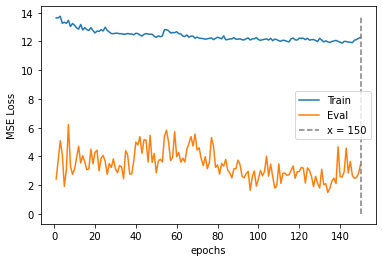

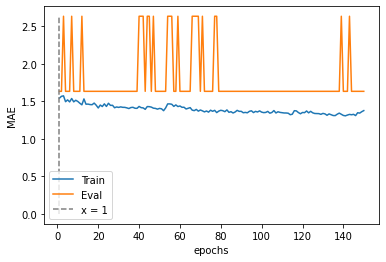

In [39]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [40]:
columns_to_keep

['x',
 'y',
 'dt_placement',
 'day',
 'month',
 'week',
 'year',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'ndvi',
 'ndwi',
 'ndmi',
 'ndbi',
 'ndvi_mean',
 'ndvi_std',
 'ndwi_mean',
 'ndwi_std',
 'ndmi_mean',
 'ndmi_std',
 'ndbi_mean',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'acc_rainfall_jan',
 'mosq_now']

In [41]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αθηνων,αττικης,23.761339,37.995939,1,1,2010,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14583.357143,14282.327273,14583.357143,NaN,NaN,NaN,14282.327273,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,ανατολικης αττικης,αττικης,23.889386,38.042726,1,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14586.219512,NaN,NaN,NaN,14249.841379,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,δυτικης αττικης,αττικης,23.393515,38.090792,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14563.811518,14194.581152,14563.811518,NaN,NaN,NaN,14194.581152,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14631.560000,14327.549296,14631.560000,NaN,NaN,NaN,14327.549296,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-02,αθηνων,αττικης,23.761339,37.995939,2,1,2010,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,14424.678571,14180.464286,14504.017857,NaN,NaN,NaN,14231.062500,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,πειραιως και νησων,αττικης,23.209892,37.000012,30,12,2022,0.450630,0.194090,-0.336309,-0.194090,0.445607,0.188515,-0.334842,-0.188515,0.050421,0.056673,0.057526,0.056673,14368.300000,14119.750000,14261.464516,14358.587500,14380.178710,14380.178710,13951.168065,13990.993929,13928.746452,13928.746452,0.000000,0.187398,1.779899,1406.339292,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981
18988,2022-12-31,αθηνων,αττικης,23.761339,37.995939,31,12,2022,0.196736,0.089225,-0.175720,-0.089225,0.201940,0.083988,-0.180670,-0.083988,0.059159,0.041055,0.047088,0.041055,14402.107143,14106.821429,14168.471774,14379.640306,14451.788594,14451.788594,13894.442972,13993.869260,13899.648041,13899.648041,0.000000,0.000000,0.384475,838.684709,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18989,2022-12-31,ανατολικης αττικης,αττικης,23.889386,38.042726,31,12,2022,0.357294,0.096638,-0.294180,-0.096638,0.350256,0.100488,-0.286339,-0.100488,0.052750,0.056148,0.048111,0.056148,14342.862069,13992.941379,14168.732703,14338.747783,14342.089878,14342.089878,13827.806229,13896.748030,13820.299889,13820.299889,0.000000,0.000380,0.115781,935.296726,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18990,2022-12-31,δυτικης αττικης,αττικης,23.393515,38.090792,31,12,2022,0.342190,0.097829,-0.273326,-0.097829,0.344352,0.098926,-0.275504,-0.098926,0.064567,0.066426,0.069173,0.066426,14331.010417,13957.661458,14110.382560,14294.838356,14340.708165,14340.708165,13799.250504,13858.337426,13799.106015,13799.106015,0.000000,0.000000,0.047329,970.382979,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [42]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep, mean_lst = True)

In [43]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [44]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [45]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [46]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [47]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

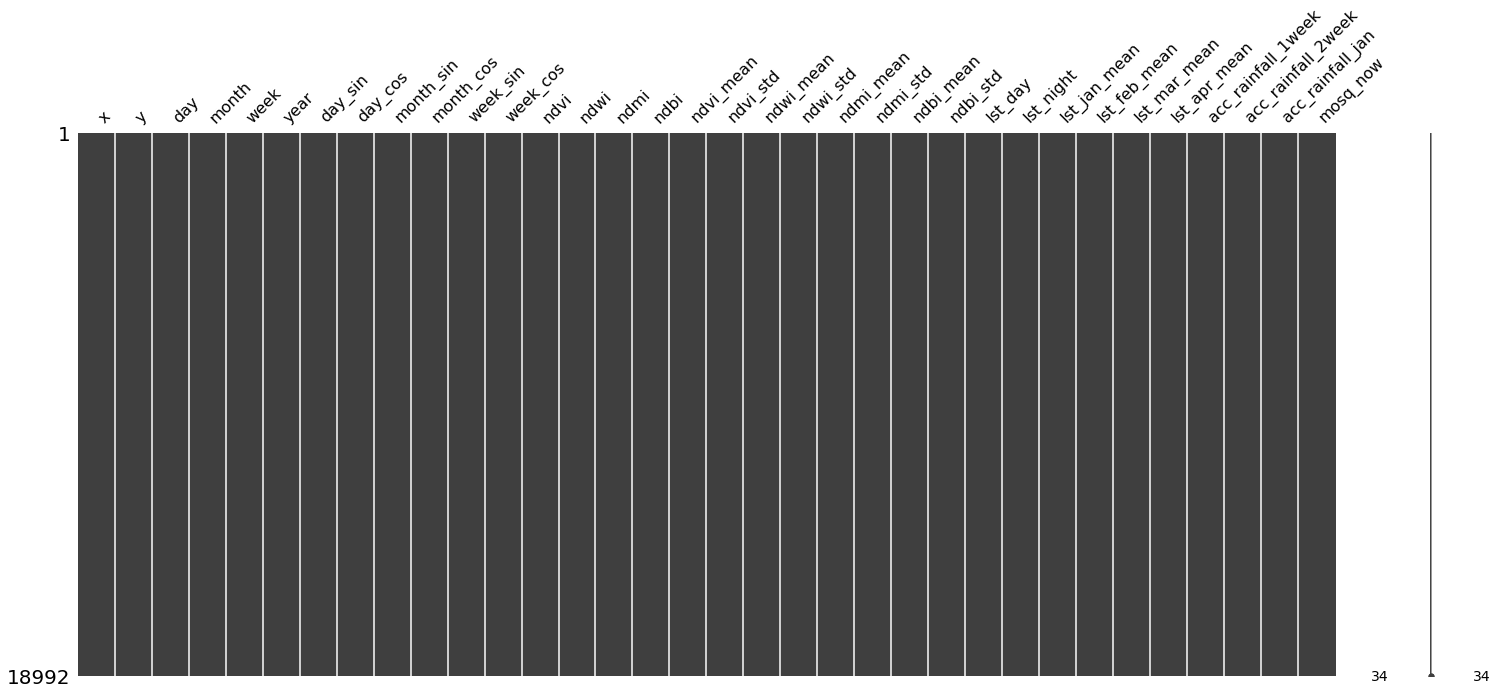

In [48]:
missingno.matrix(dataset_mamoth)

In [49]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [50]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [51]:
predictions = give_predictions(model, dataset_mamoth)

In [52]:
mosqutio_predictions['mosq_pred'] = predictions

In [53]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.761339,37.995939,2010-01-01,8
1,23.889386,38.042726,2010-01-01,31
2,23.393515,38.090792,2010-01-01,16
3,23.209892,37.000012,2010-01-01,50
4,23.761339,37.995939,2010-01-02,6
...,...,...,...,...
18987,23.209892,37.000012,2022-12-30,7
18988,23.761339,37.995939,2022-12-31,29
18989,23.889386,38.042726,2022-12-31,19
18990,23.393515,38.090792,2022-12-31,28


In [54]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', index = False)